**Statistical Validation & Interpretation**

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("cleaned_sales_dataset.csv")

In [ ]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Sales_Per_Unit
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2829.77
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,27906.16
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,37491.06
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,28541.36
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,14036.59


**Descriptive Statistics**

The descriptive statistics provide an overview of the dataset's distribution. The mean and median values help understand the central tendency, while the standard deviation measures variability in sales performance. The minimum and maximum values indicate the range of business transactions.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,41.35300,13.683626,18.00,30.0000,41.000,53.0000,65.00
Quantity,1000.0,5.43500,2.838632,1.00,3.0000,5.000,8.0000,10.00
Unit_Price,1000.0,25486.78341,14179.402361,145.78,13895.7225,25398.740,37512.3825,49997.53
Total_Sales,1000.0,139399.43965,114100.051546,437.34,47066.6325,108594.025,203722.8825,493677.50
Sales_Per_Unit,1000.0,25486.78341,14179.402361,145.78,13895.7225,25398.740,37512.3825,49997.53


**Mean, Median & Mode**

The mean represents the average sales value. The median indicates the middle value and helps identify skewness in the data. Comparing mean and median provides insight into whether extreme sales values influence the dataset.

In [ ]:
print("Mean Sales:", df['Total_Sales'].mean())
print("Median Sales:", df['Total_Sales'].median())
print("Mode Sales:")
print(df['Total_Sales'].mode())

Mean Sales: 139399.43965000001
Median Sales: 108594.025
Mode Sales:
0         437.34
1         767.61
2         771.84
3        1005.21
4        1144.78
         ...    
995    482551.90
996    485667.80
997    490866.40
998    492174.10
999    493677.50
Name: Total_Sales, Length: 1000, dtype: float64


**Standard Deviation & Variance**

Standard deviation measures the spread of sales values around the average. A higher value indicates greater variability in business performance, while a lower value suggests more consistent sales patterns.

In [ ]:
print("Standard Deviation:", df['Total_Sales'].std())
print("Variance:", df['Total_Sales'].var())

Standard Deviation: 114100.05154617467
Variance: 13018821762.839718


**Quartile Analysis**

Quartiles divide the dataset into four equal parts and help identify the distribution of sales values. They provide insights into customer purchasing behavior and revenue concentration.

In [ ]:
Q1 = df['Total_Sales'].quantile(0.25)
Q2 = df['Total_Sales'].quantile(0.50)
Q3 = df['Total_Sales'].quantile(0.75)

print("Q1:", Q1)
print("Q2 (Median):", Q2)
print("Q3:", Q3)

Q1: 47066.6325
Q2 (Median): 108594.025
Q3: 203722.8825


**Outlier Detection**

Outliers represent unusually high or low sales transactions. Identifying outliers helps businesses understand exceptional customer behavior and unusual revenue events.

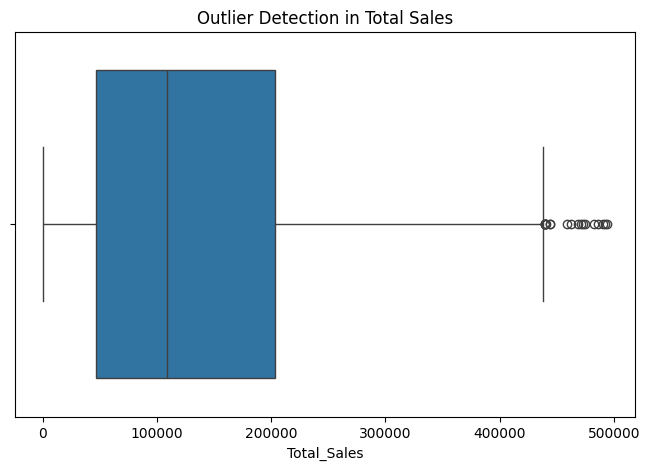

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Total_Sales'])
plt.title("Outlier Detection in Total Sales")
plt.show()

**Correlation Analysis**

Correlation analysis measures the strength and direction of relationships between variables. Strong positive correlations indicate that variables increase together, while negative correlations suggest inverse relationships.

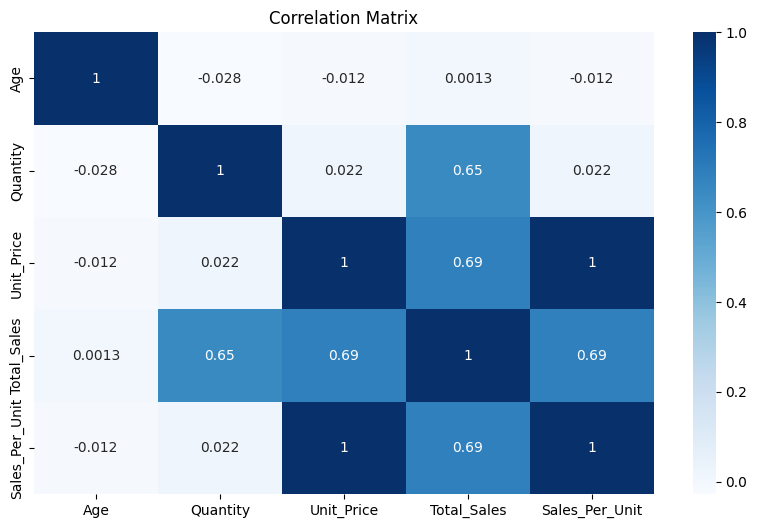

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")
plt.show()

**Distribution Analysis**

Distribution analysis helps determine whether sales values follow a normal distribution or exhibit skewness. Understanding the distribution is important for forecasting and decision-making.

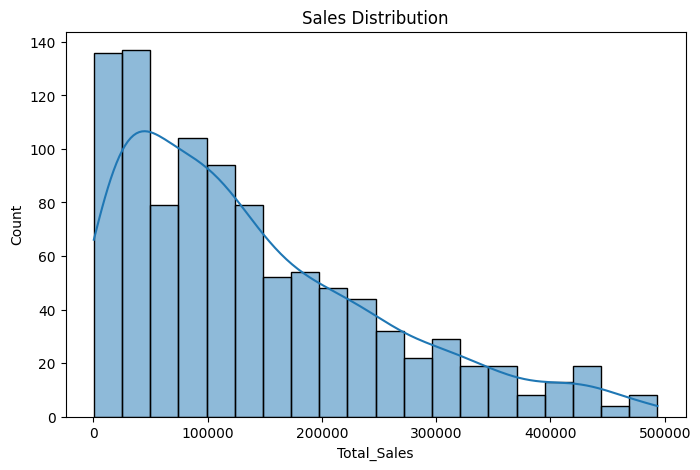

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Total_Sales'],
    bins=20,
    kde=True
)

plt.title("Sales Distribution")
plt.show()

**Customer Age Analysis**

Customer age analysis helps identify the dominant customer demographic and supports targeted marketing strategies.

In [ ]:
print("Average Age:", df['Age'].mean())
print("Youngest Customer:", df['Age'].min())
print("Oldest Customer:", df['Age'].max())

Average Age: 41.353
Youngest Customer: 18.0
Oldest Customer: 65.0


**Statistical Summary Report**

In [ ]:
summary = pd.DataFrame({
    "Metric":[
        "Total Revenue",
        "Mean Sales",
        "Median Sales",
        "Maximum Sales",
        "Minimum Sales",
        "Standard Deviation",
        "Variance",
        "Average Customer Age"
    ],
    "Value":[
        df['Total_Sales'].sum(),
        df['Total_Sales'].mean(),
        df['Total_Sales'].median(),
        df['Total_Sales'].max(),
        df['Total_Sales'].min(),
        df['Total_Sales'].std(),
        df['Total_Sales'].var(),
        df['Age'].mean()
    ]
})

summary

,Metric,Value
0,Total Revenue,1.393994e+08
1,Mean Sales,1.393994e+05
2,Median Sales,1.085940e+05
3,Maximum Sales,4.936775e+05
4,Minimum Sales,4.373400e+02
5,Standard Deviation,1.141001e+05
6,Variance,1.301882e+10
7,Average Customer Age,4.135300e+01


**Skewness Analysis**

Skewness measures the asymmetry of the sales distribution.

If Skewness > 0:
The distribution is positively skewed, indicating a few high-value transactions.

If Skewness < 0:
The distribution is negatively skewed.

If Skewness ≈ 0:
The distribution is approximately symmetrical.

In [ ]:
from scipy.stats import skew

sales_skewness = skew(df['Total_Sales'])

print("Skewness:", sales_skewness)

Skewness: 0.9865373304391132


**Kurtosis Analysis**

Kurtosis measures the heaviness of the tails of a distribution.

High kurtosis indicates the presence of extreme sales values.

Low kurtosis indicates fewer extreme observations.

In [ ]:
from scipy.stats import kurtosis

sales_kurtosis = kurtosis(df['Total_Sales'])

print("Kurtosis:", sales_kurtosis)

Kurtosis: 0.2911813072728937


**Confidence Interval**

The confidence interval estimates the range within which the true average sales value is expected to lie with 95% confidence.

This provides statistical reliability for business decisions.

In [ ]:
import scipy.stats as stats
import numpy as np

confidence = 0.95

mean = np.mean(df['Total_Sales'])
sem = stats.sem(df['Total_Sales'])

ci = stats.t.interval(
    confidence,
    len(df['Total_Sales'])-1,
    loc=mean,
    scale=sem
)

print("95% Confidence Interval:", ci)

95% Confidence Interval: (np.float64(132318.9968196067), np.float64(146479.88248039334))


**Shapiro-Wilk Test**

H0: Data follows a normal distribution.
H1: Data does not follow a normal distribution.

If p > 0.05:
Accept H0 (normally distributed)

If p < 0.05:
Reject H0 (not normally distributed)

In [ ]:
from scipy.stats import shapiro

stat, p = shapiro(df['Total_Sales'])

print("Statistic:", stat)
print("P-value:", p)

Statistic: 0.9064048564003137
P-value: 2.7925465018370795e-24


**Hypothesis Testing**

***Gender-Based Sales Comparison***

In [ ]:
from scipy.stats import ttest_ind

male_sales = df[df['Gender']=="Male"]['Total_Sales']
female_sales = df[df['Gender']=="Female"]['Total_Sales']

t_stat, p_val = ttest_ind(
    male_sales,
    female_sales
)

print("T Statistic:", t_stat)
print("P-value:", p_val)

T Statistic: 0.6820125406168254
P-value: 0.4953892684482486


**Z-Score Analysis**

**Outlier Validation**

Z-score identifies observations significantly different from the average.

Values beyond ±3 are considered potential outliers.

In [ ]:
from scipy.stats import zscore

df['Z_Score'] = zscore(df['Total_Sales'])

outliers = df[
    (df['Z_Score'] > 3) |
    (df['Z_Score'] < -3)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 5


**Business Significance Analysis**

**Category Performance Ranking**

Ranking categories helps identify revenue-driving business segments and prioritize resource allocation.

In [ ]:
category_rank = df.groupby(
    'Category'
)['Total_Sales'].sum().sort_values(
    ascending=False
)

print(category_rank)

Category
Electronics    50778581.70
Education      25031689.40
Grocery        22231711.28
Furniture      21521561.48
Fashion        19835895.79
Name: Total_Sales, dtype: float64
